In [17]:
gfa_file_path:str = "pggb_yeast_1.gfa"
vcf_file_path:str = "pggb_yeast_1.vcf"
masked_vcf = "pggb_yeast_1.mask.vcf"
reference_name:str = "CASBJU01"
alternative_name:str = "CASBIT01"


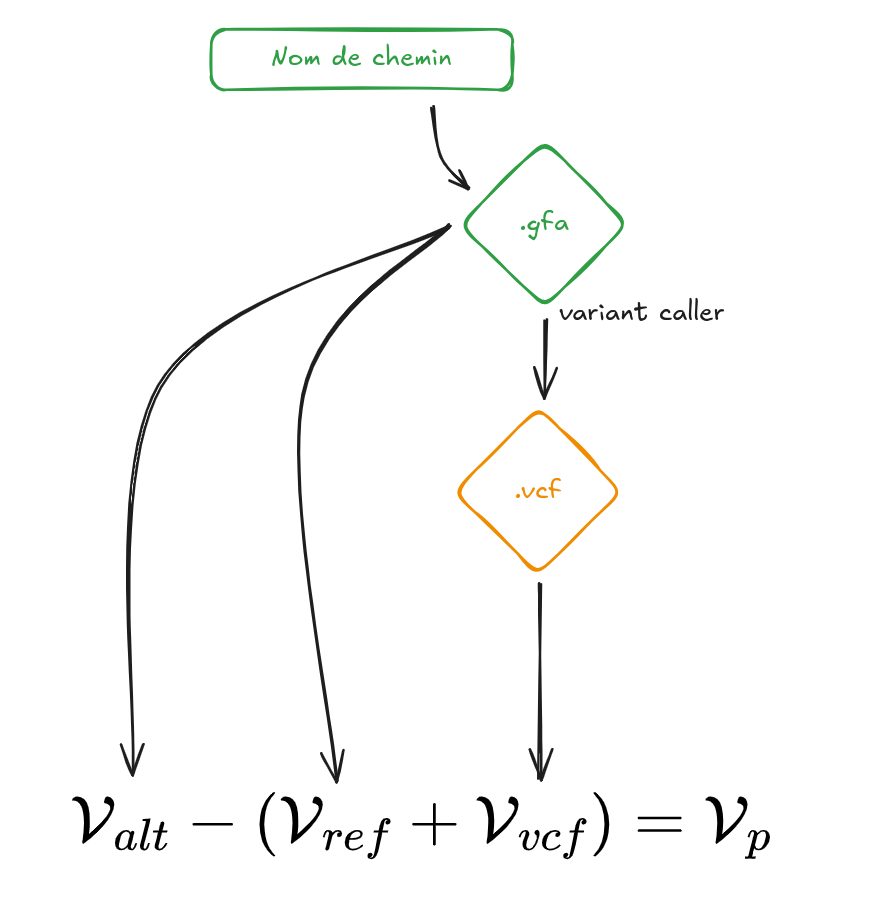


Etape 1 : charger le GFA et obtenir tous les labels des noeuds sous forme d'un set

In [18]:
reference_gfa_set:set = set()
alternative_gfa_set:set = set()
sequences_dict:dict = dict()

with open(gfa_file_path,'r',encoding='utf-8') as gfa_reader:
    for line in gfa_reader:
        if line.startswith('S'):
            sequences_dict[line.split('\t')[1]] = line.strip().split('\t')[2]
        if line.startswith('P') and reference_name in line.split('\t')[1]:
            for x in line.split('\t')[2].split(','):
                reference_gfa_set.add(int(x[:-1]))
        if line.startswith('P') and alternative_name in line.split('\t')[1]:
            for x in line.split('\t')[2].split(','):
                alternative_gfa_set.add(int(x[:-1]))

print("Number of nodes in graph: " + str(len(sequences_dict)))

print(reference_name + ": " + str(len(reference_gfa_set)) + " nodes ("+ str(sum([len(sequences_dict[str(x)]) for x in reference_gfa_set])) +" bp)")
print(alternative_name +": "+ str(len(alternative_gfa_set)) + " nodes ("+ str(sum([len(sequences_dict[str(x)]) for x in alternative_gfa_set])) +" bp)")

private_alternative_set:set = alternative_gfa_set - reference_gfa_set
print(alternative_name + " - " + reference_name + ": " + str(len(private_alternative_set)) + " nodes ("+ str(sum([len(sequences_dict[str(x)]) for x in private_alternative_set])) +" bp)")

Number of nodes in graph: 27213
CASBJU01: 16575 nodes (214140 bp)
CASBIT01: 14093 nodes (197082 bp)
CASBIT01 - CASBJU01: 1540 nodes (4602 bp)


In [19]:
print(','.join([str(x) for x in reference_gfa_set]))

2,3,4,5,7,8,10,11,13,14,15,16,18,19,21,23,24,26,27,29,30,32,33,35,36,38,39,41,42,44,45,46,48,49,51,53,54,55,57,59,60,62,63,65,66,68,69,71,72,74,75,76,78,80,81,83,84,85,87,89,90,91,93,94,96,98,99,101,102,104,105,107,108,110,111,112,114,115,117,119,120,122,124,125,127,128,130,131,133,134,136,137,139,140,142,143,145,146,148,149,151,152,154,155,157,158,160,162,163,165,166,169,170,171,173,174,175,177,179,180,181,183,184,186,187,189,191,192,195,196,197,199,200,202,203,205,206,208,209,211,213,214,216,217,219,220,221,222,224,225,227,228,230,231,232,234,236,237,239,240,242,243,246,247,248,250,251,253,254,256,257,259,260,262,263,265,266,268,269,271,272,274,275,277,278,280,281,282,283,285,286,288,289,290,292,294,295,296,298,300,301,303,304,305,307,309,310,312,313,315,316,318,319,321,322,324,325,327,328,330,331,333,334,336,337,339,340,341,343,345,346,348,349,351,352,353,355,356,357,359,360,362,364,365,367,368,370,371,372,374,376,377,378,380,382,383,385,386,388,389,391,392,393,395,396,397,399,400,4

In [20]:
print(','.join([str(x) for x in alternative_gfa_set]),file=open("alternative_gfa_set.txt",'w'))

In [21]:
print(','.join([str(x) for x in alternative_gfa_set.intersection(reference_gfa_set)]))

2,3,4,5,7,8,10,11,13,14,15,21,23,24,26,27,29,30,32,33,35,36,38,39,41,42,44,45,48,51,53,54,55,57,59,60,62,63,65,66,68,69,71,72,74,75,76,78,80,81,83,84,87,89,90,91,93,96,98,99,102,104,105,107,108,110,111,114,115,117,119,120,122,124,125,127,128,130,131,133,134,136,137,139,140,142,143,145,146,148,149,151,152,154,155,157,158,160,162,163,165,166,169,170,171,173,174,175,177,179,180,181,183,184,186,187,189,191,192,195,196,197,199,200,202,203,205,206,208,209,211,213,214,216,217,219,220,221,222,225,227,228,230,231,232,234,236,237,239,240,242,243,246,247,248,250,251,253,254,256,257,259,260,262,263,265,266,268,269,271,272,274,275,277,278,280,281,282,283,285,286,288,289,292,294,295,296,298,300,301,303,304,307,309,310,312,313,315,316,318,319,321,322,324,325,327,328,330,331,333,334,336,337,339,340,341,343,345,346,348,349,351,352,353,355,356,357,359,360,362,364,365,368,370,371,372,374,376,380,382,383,385,386,388,389,391,392,393,395,396,397,399,400,401,402,404,405,406,407,409,410,411,413,415,416,418,41

In [22]:
print(','.join([str(x) for x in alternative_gfa_set.union(reference_gfa_set)]),file=open("gfa_set.txt",'w'))

Etape 2 : obtenir les labels des noeuds dans le VCF qui décrivent de la variation

In [23]:
from collections import Counter

alternative_vcf_set:set = set()
headers:list = list()
alt_pos:int = 0
incorrects_formattings:list[str] = list()

with open(vcf_file_path,'r',encoding='utf-8') as vcf_reader:
    for line in vcf_reader:
        if line.startswith('##'):
            continue
        elif line.startswith('#'):
            headers = line.split('\t')
            alt_pos = headers.index(alternative_name)
        else:
            # on check si le genome alt est décrit en génotype par un entier 1...n
            try:
                has_variant:int = int(line.split('\t')[alt_pos])
            except:
                incorrects_formattings.append(line.split('\t')[alt_pos])
                has_variant:int = -1
            # si c'est 0 ou -1, c'est que ce n'est pas correctement décrit comme variant
            if has_variant > 0:
                # On doit aller chercher la bonne position du variant dans le champ AT (pas besoin de conserver le sens)
                alternative_vcf_set.update([int(x) for x in line.split('\t')[7].split(';')[3].split(',')[has_variant].replace('<','>')[1:].split('>')])

print(len(alternative_vcf_set))

print(len(incorrects_formattings))

print(Counter(incorrects_formattings))


resulting_set:set = private_alternative_set - alternative_vcf_set

print(len(resulting_set))



11464
1571
Counter({'.': 1571})
229


In [24]:
print(','.join([str(x) for x in resulting_set]))

22016,23040,22018,22019,23041,22021,23043,22023,22024,22025,23044,22027,22028,23047,22030,22031,23049,22033,22034,20499,22036,22037,23055,22039,22040,23056,22042,23058,22044,22045,23061,22047,22048,22049,23067,22051,23069,22053,22054,23070,22056,22057,23074,22059,22060,23076,22062,22063,23079,22065,22066,23082,22068,22069,22070,22072,22074,22075,22077,22078,22080,22081,22083,22084,22086,22087,22088,22090,22092,22093,22095,22096,22098,22099,22101,22102,22104,22105,22107,22108,22110,22111,23134,22113,22114,22115,23136,22117,23138,22119,22120,23139,22122,23140,22124,22125,23143,22127,22128,23145,22130,22131,23147,22133,22135,22136,22137,23031,23033,23035,23036,23037,23039,23146,23050,23052,23057,23059,23062,23064,22865,22866,22869,22872,22874,22875,22876,22881,22882,22884,22885,22891,22892,23071,22894,22895,22897,23072,22904,22906,22907,22909,22911,22912,22914,22915,22916,22918,22920,22922,23077,22925,22926,22927,22930,22931,22932,22935,22936,22937,22939,22941,22942,22943,22944,22946,2295

In [25]:
print(','.join([str(x) for x in alternative_vcf_set]))

2,3,4,5,7,8,10,11,13,14,15,20,21,23,24,26,27,29,30,32,33,35,36,38,39,41,42,44,45,47,48,50,51,53,54,55,57,59,60,62,63,65,66,68,69,71,72,74,75,76,78,80,81,83,84,86,87,89,90,91,93,95,96,98,99,100,102,104,105,107,108,110,111,113,114,115,117,119,120,122,124,125,127,128,130,131,133,134,136,137,139,140,142,143,145,146,148,149,151,152,154,155,157,158,160,162,163,165,166,169,170,171,173,174,175,177,179,180,181,183,184,186,187,189,191,192,195,196,197,199,200,202,203,205,206,208,209,211,213,214,216,217,219,220,221,222,223,225,227,228,230,231,232,234,236,237,239,240,242,243,246,247,248,250,251,253,254,256,257,259,260,262,263,265,266,268,269,271,272,274,275,277,278,280,281,282,283,285,286,288,289,291,292,294,295,296,298,300,301,303,304,306,307,309,310,312,313,315,316,318,319,321,322,324,325,327,328,330,331,333,334,336,337,339,340,341,343,345,346,348,349,351,352,353,355,356,357,359,360,362,364,365,366,368,370,371,372,374,376,379,380,382,383,385,386,388,389,391,392,393,395,396,397,399,400,401,402,404

On vérifie que les morceaux ne sont pas décrits comme des variants

In [26]:
with open(vcf_file_path,'r',encoding='utf-8') as vcf_reader:
    for line in vcf_reader:
        if line.startswith('##'):
            continue
        elif line.startswith('#'):
            headers = line.split('\t')
            alt_pos = headers.index(alternative_name)
        else:
            # on check si le genome alt est décrit en génotype par un entier 1...n
            try:
                has_variant:int = int(line.split('\t')[alt_pos])
            except:
                incorrects_formattings.append(line.split('\t')[alt_pos])
                has_variant:int = -1
            # si c'est 0 ou -1, c'est que ce n'est pas correctement décrit comme variant
            if has_variant > 0:
                # On doit aller chercher la bonne position du variant dans le champ AT (pas besoin de conserver le sens)
                y:list = [int(x) for x in line.split('\t')[7].split(';')[3].split(',')[has_variant].replace('<','>')[1:].split('>')]
                if any([x in resulting_set for x in y]):
                    print(line)

On va rechercher comment ces non-variants s'inscrivent dans le graphe. Ont-ils des liens à la référence ? Sont-ils encadrés, de près ou de loin, à des noeuds appartenant à la référence ?

In [27]:
alternative_gfa_list:list = list()
alternative_gfa_strs:list = list()

with open(gfa_file_path,'r',encoding='utf-8') as gfa_reader:
    for line in gfa_reader:
        if line.startswith('P') and alternative_name in line.split('\t')[1]:
            for x in line.split('\t')[2].split(','):
                alternative_gfa_list.append(int(x[:-1]))
                alternative_gfa_strs.append(x)

print(len(alternative_gfa_list))

15410


On va chercher les index des noeuds qui font partie de notre set de non-variants, définir un cutoff, et chercher si les noeuds à droite et gauche jusqu'au cutoff ou avant sont dans l'intersection

In [28]:
intersect:set = alternative_gfa_set.intersection(reference_gfa_set)

count_rescuables_nodes:int = 0
node_pairs:set[tuple] = set()
chains_list:list = list()

for node_id in resulting_set:
    idx:int = alternative_gfa_list.index(node_id)
    bubble_branch:list = [alternative_gfa_strs[idx]]
    # We assume we have a single occurence, we search the first index
    cutoff:int = min(int(len(alternative_gfa_list)/10),idx,len(alternative_gfa_list)-idx) -1
    x,y = 0,0
    dist = 1
    while not x and cutoff >= dist:
        bubble_branch = [alternative_gfa_strs[idx-dist]] + bubble_branch
        if alternative_gfa_list[idx-dist] in intersect:
            x = alternative_gfa_list[idx-dist]
        dist+=1
    dist = 1
    while not y and cutoff >= dist:
        bubble_branch = bubble_branch + [alternative_gfa_strs[idx+dist]]
        if alternative_gfa_list[idx+dist] in intersect:
            y = alternative_gfa_list[idx+dist]
        dist+=1
    if x and y:
        count_rescuables_nodes+=1
        node_pairs.add((x,y))
        chains_list.append(bubble_branch)
print(f"Graph contains at least {count_rescuables_nodes} rescuable nodes ({round(count_rescuables_nodes/len(resulting_set)*100,2)}%).")


Graph contains at least 82 rescuable nodes (35.81%).


On va chercher à obtenir les chaînes pour les observer. Peut-on trouver les chaînes dans la référence et récupérer les variants ?

In [29]:
# Nombre de bubbles à secourir
len(node_pairs)

3

In [30]:
reference_gfa_list:list = list()
reference_gfa_strs:list = list()

with open(gfa_file_path,'r',encoding='utf-8') as gfa_reader:
    for line in gfa_reader:
        if line.startswith('P') and reference_name in line.split('\t')[1]:
            for x in line.split('\t')[2].split(','):
                reference_gfa_list.append(int(x[:-1]))
                reference_gfa_strs.append(x)

print(len(reference_gfa_list))

18138


In [31]:
def revcomp(string: str, compl: dict = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A', 'N': 'N'}) -> str:
    """Tries to compute the reverse complement of a sequence

    Args:
        string (str): original character set
        compl (dict, optional): dict of correspondances. Defaults to {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}.

    Raises:
        IndexError: Happens if revcomp encounters a char that is not in the dict

    Returns:
        str: the reverse-complemented string
    """
    try:
        return ''.join([compl[s] for s in string][::-1])
    except IndexError as exc:
        raise IndexError(
            "Complementarity does not include all chars in sequence.") from exc

In [32]:
bubbles_dict = dict()
bubbles_positions = dict()
bubbles_positions_alt = dict()

for a,b in node_pairs:
    idx_a,idx_b = reference_gfa_list.index(a),reference_gfa_list.index(b)
    bubbles_dict[(a,b)] = reference_gfa_strs[min(idx_a,idx_b):max(idx_a+1,idx_b+1)]
    bubbles_positions[(a,b)] = sum([len(sequences_dict[x[:-1]]) for x in reference_gfa_strs[0:min(idx_a,idx_b)]])
    bubbles_positions_alt[(a,b)] = sum([len(sequences_dict[x[:-1]]) for x in alternative_gfa_strs[0:min(idx_a,idx_b)]])

# Observer si les bubbles sont imbriquées

+ Parser le VCF
+ extraire les chaînes liées à la référence
+ intersection entre les E/S de la bubble détectée et des chaînes de référence dans le VCF
+ taille de l'intersection = statut (0 => non imbriquée, 1 => chevauchant, 2 => imbriqué avec ou sans cycle)
+ 

In [33]:
reference_chains:list[list[int]] = list()

with open(vcf_file_path,'r',encoding='utf-8') as vcf_reader:
    for line in vcf_reader:
        if line.startswith('##') or line.startswith('#'):
            continue
        else:
            # on récupère la chaîne de référence
            reference_chains.append([int(x) for x in line.split('\t')[7].split(';')[3].split(',')[0].replace('<','>')[4:].split('>')])

In [34]:
masked_bubbles:list = list()

with open(masked_vcf,'r') as vcf_reader:
    for line in vcf_reader:
        if line.startswith('#'):
            continue
        else:
            masked_bubbles.append(line.split('\t')[2])

In [ ]:
from os.path import exists
from os import remove


if exists('branches_yeast_1.txt'):
    remove('branches_yeast_1.txt')

pairlist = list()

for bubble in chains_list:
    bubble_name = ('>' if bubble[0][-1] == '+' else '<')+bubble[0][:-1]+('>' if bubble[-1][-1] == '+' else '<')+bubble[-1][:-1]
    bubble_anchors:set[int] = {int(bubble[0][:-1]),int(bubble[1][:-1])}
    intricate = [len(bubble_anchors.intersection(x[1:-1])) for x in reference_chains]
    if sum(intricate) == 0:
        status = '0'
    else:
        intricate = sorted([x for x in intricate if x != 0])
        if intricate[0] == 1 and intricate[-1] == 2:
            status = '1|2'
        else:
            status = str(intricate[0])

    if bubble_name in pairlist:
        continue
    else:
        pairlist.append(bubble_name)
        print(
            reference_name+
            '\t'+
            str(bubbles_positions[(int(bubble[0][:-1]),int(bubble[-1][:-1]))])+
            '\t'+
            str(bubbles_positions_alt[(int(bubble[0][:-1]),int(bubble[-1][:-1]))])+
            '\t'+
            bubble_name+
            '\t'+
            ''.join([sequences_dict[idd[:-1]] if idd[-1] == '+' else revcomp(sequences_dict[idd[:-1]]) for idd in bubbles_dict[(int(bubble[0][:-1]),int(bubble[-1][:-1]))]][1:-1])+
            '\t'+
            ''.join([sequences_dict[idd[:-1]] if idd[-1] == '+' else revcomp(sequences_dict[idd[:-1]]) for idd in bubble][1:-1])+
            '\t'+'60'+
            '\t'+'.'+
            "\t"+
            "AC="+";"+
            "AF="+";"+
            "AN="+";"+
            "AT="+
            ''.join([(">" if idd[-1] == '+' else '<')+str(idd)[:-1] for idd in bubbles_dict[(int(bubble[0][:-1]),int(bubble[-1][:-1]))]])+','+''.join([(">" if idd[-1] == '+' else '<')+str(idd)[:-1] for idd in bubble])+";"+
            "NS="+";"+
            "LV="+";"+
            "RS="+str(int(bubble_name in masked_bubbles))+";"+
            "IT="+status
            ,file=open("branches_yeast_1.vcf",'a+')
        )
        print()
        print(','.join([str(idd)[:-1] for idd in bubbles_dict[(int(bubble[0][:-1]),int(bubble[-1][:-1]))]])+'\n'+','.join([str(idd)[:-1] for idd in bubble]))
        print()


22232,22229,22217,22216,22214,22209,22188,22187,22170,22168,22165,22163,22156,22151,22146,22144,22141,22140,21995,21993,21992,21991,21989,21985,21983,21982,21980,21979,21977,21976,21974,21972,21971,21969,21967,21965,21964,21962,21961,21957,21956,21955,21953,21952,21950,21949,21947,21946,21943,21942,21940,21939,21937,21936,21934,21931,21930,21927,21924,21923,21921,21920,21918,21917,21915,21914,21912,21911,21909,21908,21906,21905,21903,21902,21900,21899,21897,21896,21894,21893,21892,21889,21887,21885,21884,21883,21881,21880,21878,21877,21875,21874,21872,21871,21869,21867,21866,21863,21862,21860,21858,21857,21855,21854,21852,21851,21849,21848,21846,21845,21841,21838,21837,21835,21834,21832,21831,21829,21827,21826,21824,21822,21821,21820,21817,21815,21814,21812,21811,21809,21808,21806,21805,21803,21802,21801,21800,21796,21795,21794,21792,21790,21787,21785,21784,21782,21781,21779,21778,21776,21775,21773,21772,21770,21769,21767,21765,21764,21763,21762,21758,21757,21755,21754,21752,21750,217

./rs-pancat-paths pggb_yeast_1.gfa -M CASBIW01 -M CASBIZ01 -M CASBJG01 -M CASBJH01 -M CASBJI01 -M CASBJJ01 -M CASBJL01 -M CASBJM01 -M CASBJN01 -M CASBJQ01 -M CASBJS01 -M CASBJT01 -M CASBJV01 > pggb_yeast_1.mask.gfa

vg deconstruct -a -p CASBJU01 pggb_yeast_1.mask.gfa > pggb_yeast_1.mask.vcf